# Network Intrusion Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Task 1: Data exploration + plots

###  Load the CSV with pandas and print the shape, the first few rows, and df.describe().

In [2]:
# loading the file , hope path is correct lol
df=pd.read_csv("dataset/network_traffic.csv")

df.shape    # just checking rows and cols


(6000, 16)

In [3]:
# lets see first few rows of data
df.head()


,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
0,0,244,3252,0,0,1,0,16,16,0.0,1.00,0.00,34,255,1.00,0
1,0,8,0,0,0,0,0,1,21,0.0,1.00,0.00,1,41,1.00,1
2,0,242,5278,0,0,1,0,6,11,0.0,1.00,0.00,255,255,1.00,0
3,0,45,76,0,0,0,0,161,161,0.0,1.00,0.00,255,203,0.80,0
4,0,1,0,0,0,0,0,13,2,0.0,0.15,0.15,255,29,0.11,1


In [4]:
# this gives us the stats like mean std min max etc
df.describe()


,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
count,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,413.933000,1.603307e+04,2.951740e+03,0.028333,0.206167,0.385000,0.179667,80.434500,27.572333,0.293578,0.658218,0.060692,180.643333,112.433000,0.519193,0.500000
std,3237.030266,3.049754e+05,7.057366e+04,0.283803,2.120632,0.486636,8.981360,108.869318,70.945265,0.451700,0.438878,0.170613,99.879900,108.894863,0.445222,0.500042
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.100000,0.000000,79.000000,11.000000,0.050000,0.000000
50%,0.000000,4.300000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,1.000000,0.000000,255.000000,60.000000,0.490000,0.500000
75%,0.000000,2.730000e+02,4.550000e+02,0.000000,0.000000,1.000000,0.000000,135.250000,18.000000,1.000000,1.000000,0.060000,255.000000,255.000000,1.000000,1.000000
max,42569.000000,1.698050e+07,5.149533e+06,3.000000,30.000000,1.000000,520.000000,511.000000,511.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000


### Plot the class distribution (a bar chart of the label column).

In [5]:
count_label=df['label'].value_counts().sort_index()
#.value_counts()counts how many 0s and how many 1s in label column
#.sort_index() so 0 come before 1 in output
count_label


label
0    3000
1    3000
Name: count, dtype: int64

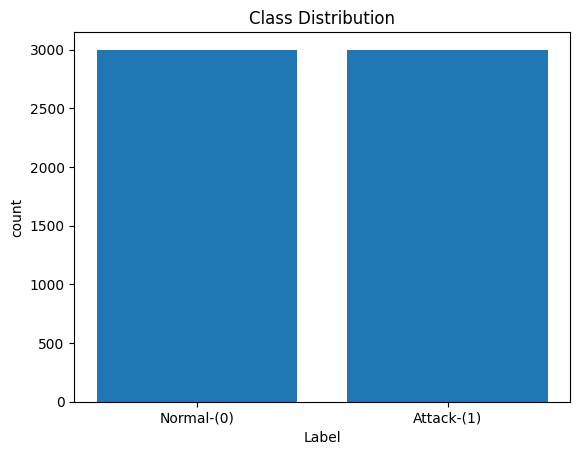

In [6]:
# bar chart to see if data is balance or not
plt.bar(['Normal-(0)','Attack-(1)'],count_label.values)
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('count')
plt.savefig('task1_class_dist.png', bbox_inches='tight')
plt.show()


###  Plot at least two feature histograms (e.g. src_bytes and count) with one histogram per class on the same axes so you can see where normal and attack traffic differ.

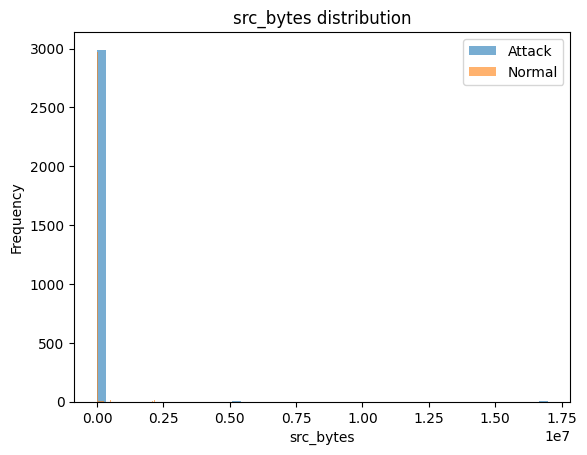

In [7]:
# spliting data into normal and attack so we can plot them sepratly
normal=df[df['label']==0]
attack=df[df['label']==1]

# src_bytes histogram for both class on same plot
# alpha make it transparent so we can see both
plt.hist(attack['src_bytes'],bins=50,alpha=0.6,label='Attack')
plt.hist(normal['src_bytes'],bins=50,alpha=0.6,label='Normal')

plt.title('src_bytes distribution')
plt.xlabel('src_bytes')
plt.ylabel('Frequency')
plt.legend()
plt.show()


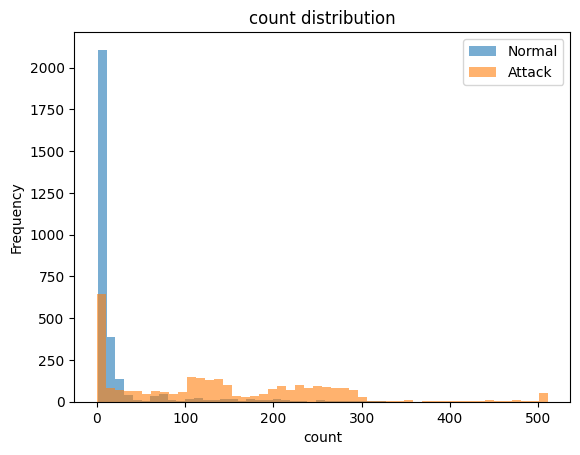

In [8]:
# now count feature histogram
plt.hist(normal['count'],bins=50,alpha=0.6,label='Normal')
plt.hist(attack['count'],bins=50,alpha=0.6,label='Attack')

plt.title('count distribution')
plt.xlabel('count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('task1_hist1.png', bbox_inches='tight')
plt.show()


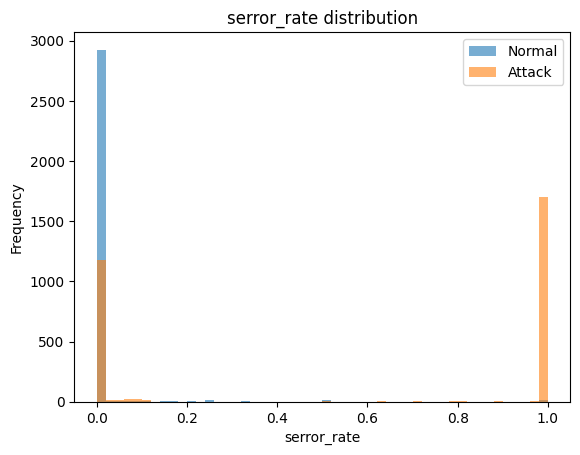

In [9]:
# serror_rate histogram , this one show biggest differnce between normal and attack
plt.hist(normal['serror_rate'], bins=50, alpha=0.6, label='Normal')
plt.hist(attack['serror_rate'], bins=50, alpha=0.6, label='Attack')

plt.title('serror_rate distribution')
plt.xlabel('serror_rate')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Task 2: Simple reflex agent 

In [10]:
# importing accuracy and confusoin matrix from sklearn
from sklearn.metrics import accuracy_score,confusion_matrix


In [11]:
# simple reflex agent function
# it look at one row and decide if its attack or normal using if else rules
# no memory , no learning , just rules
def reflex_agent(row):
    if row['serror_rate']>0.5:   # error rate is to high means attack
        return 1
    if row['same_srv_rate']<0.4:  # service rate is low also suspisious
        return 1
    if row['count']>200:   # to many connections is also sign of attack
        return 1
    return 0    # if all ok then normal


In [12]:
# apply the agent to every row in dataset using apply function
# axis=1 means go row by row not column
df['predicted']=df.apply(reflex_agent,axis=1)


In [13]:
# now check how many prediction are correct
accuracy=accuracy_score(df['label'],df['predicted'])
print(f'Accuracy: {accuracy*100}%')


Accuracy: 86.0%


In [14]:
# confusion matrix tell us exactly where agent is right and where it is wrong
# TP = attack predicted as attack (correct)
# TN = normal predicted as normal (correct)
# FP = normal predicted as attack (wrong)
# FN = attack predicted as normal (wrong) this is the most dangerous one
cm = confusion_matrix(df['label'], df['predicted'])
print('Confusion Matrix:')
print(f'TN={cm[0][0]}  FP={cm[0][1]}')
print(f'FN={cm[1][0]}  TP={cm[1][1]}')


TN,FP,FN,TP= cm[0][0],cm[0][1],cm[1][0],cm[1][1]

# calculate precision and recall manualy from cm values
precision=TP/(TP + FP)
recall=TP/(TP + FN)

print(f'Precision:{precision*100}%')
print(f'Recall   :{recall*100}%')


Confusion Matrix:
TN=2852  FP=148
FN=692  TP=2308
Precision:93.97394136807817%
Recall   :76.93333333333334%


# Task 3: KNN + Naïve Bayes + Logistic Reg. 

### 1.KNN


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X is all columns except label , y is the label column
X = df.drop('label',axis=1)
y = df['label']

# splitting 80% train 20% test
# stratify=y make sure both splits have equal 0s and 1s
# random_state=42 so split is same every time we run
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# scaling is important for knn and lr
# without it src_bytes(thousands) will dominate serror_rate(0 to 1) in distance calc
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)   # fit only on train not test
X_test_scaled=scaler.transform(X_test)          # just transform test


K= 1 Accuracy: 0.96
K= 3 Accuracy: 0.95
K= 5 Accuracy: 0.95
K= 7 Accuracy: 0.95
K= 9 Accuracy: 0.95
K= 11 Accuracy: 0.95


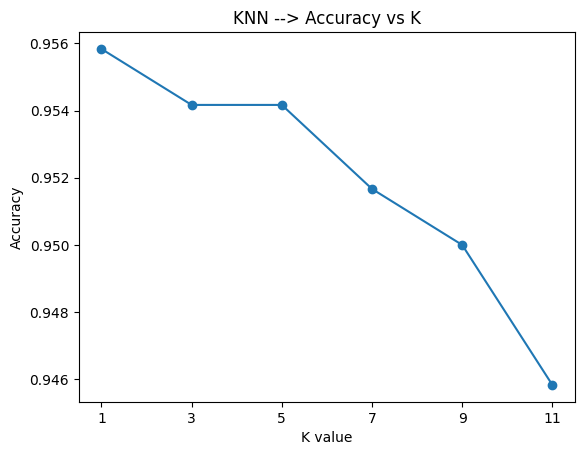

In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# try diffrent k values and see which one is best
k_values=[1,3,5,7,9,11]
scores=[]

for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled,y_train)
    y_pred=knn.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_pred)
    scores.append(acc)
    print('K=',k, 'Accuracy:',round(acc,2))

# plot to see which k is best visually
plt.plot(k_values,scores,marker='o')
plt.title('KNN --> Accuracy vs K')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.savefig('task3_knn_k.png', bbox_inches='tight')
plt.show()


In [17]:
# pick the k with highest accuracy
best_k=k_values[scores.index(max(scores))]
print("The best k is : ",best_k)

# retrain with best k
knn_best=KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled,y_train)
y_pred_knn=knn_best.predict(X_test_scaled)


The best k is :  1


In [18]:
# confusion matrix and all metrics for knn
print('Confusion Matrix:\n')
cm=confusion_matrix(y_test, y_pred_knn)
print(f'TN={cm[0][0]}  FP={cm[0][1]}')
print(f'FN={cm[1][0]}  TP={cm[1][1]}\n')

print('Accuracy :',round(accuracy_score(y_test, y_pred_knn),4))
print('Precision:',round(precision_score(y_test, y_pred_knn),4))
print('Recall   :',round(recall_score(y_test, y_pred_knn),4))
print('F1 Score :',round(f1_score(y_test, y_pred_knn),4))


Confusion Matrix:

TN=567  FP=33
FN=20  TP=580

Accuracy : 0.9558
Precision: 0.9462
Recall   : 0.9667
F1 Score : 0.9563


### 2.Naive Bayes

In [19]:
from sklearn.naive_bayes import GaussianNB

# naive bayes dont need scaling it work on probability
nb=GaussianNB()
nb.fit(X_train,y_train)   # train on unscaled data
y_pred_nb=nb.predict(X_test)

cm=confusion_matrix(y_test,y_pred_nb)
print('Confusion Matrix:\n')
print(f'TN={cm[0][0]}  FP={cm[0][1]}')
print(f'FN={cm[1][0]}  TP={cm[1][1]}\n')

print('Accuracy :',round(accuracy_score(y_test, y_pred_nb),4))
print('Precision:',round(precision_score(y_test, y_pred_nb),4))
print('Recall   :',round(recall_score(y_test, y_pred_nb),4))
print('F1 Score :',round(f1_score(y_test, y_pred_nb),4))


Confusion Matrix:

TN=575  FP=25
FN=230  TP=370

Accuracy : 0.7875
Precision: 0.9367
Recall   : 0.6167
F1 Score : 0.7437


### 3.Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

# logistic regression need scaling same like knn
# max_iter=1000 so it dont stop early before converging
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)
y_pred_lr=lr.predict(X_test_scaled)

cm=confusion_matrix(y_test,y_pred_lr)
print('Confusion Matrix:\n')
print(f'TN={cm[0][0]}  FP={cm[0][1]}')
print(f'FN={cm[1][0]}  TP={cm[1][1]}\n')

print('Accuracy :',round(accuracy_score(y_test, y_pred_lr),4))
print('Precision:',round(precision_score(y_test, y_pred_lr),4))
print('Recall   :',round(recall_score(y_test, y_pred_lr),4))
print('F1 Score :',round(f1_score(y_test, y_pred_lr),4))


Confusion Matrix:

TN=560  FP=40
FN=58  TP=542

Accuracy : 0.9183
Precision: 0.9313
Recall   : 0.9033
F1 Score : 0.9171


# Task 4: K-Means clustering

In [21]:
import math

# same euclidean distance we did in lab
# calculates straight line distance between 2 points
def euclidean_distance(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total = total + (diff * diff)  # square the diff and add
    return math.sqrt(total)   # square root at end


In [22]:
# find which centroid is nearest to a given point
def get_closest_centroid(point, centroids):
    min_dist = float('inf')   # start with infinity so any dist will be smaller
    closest_index = -1

    for i in range(len(centroids)):
        dist = euclidean_distance(point, centroids[i])
        if dist < min_dist:
            min_dist = dist
            closest_index = i   # update closest

    return closest_index


In [23]:
# recalculate centroids as mean of all points in that cluster
def update_centroids(clusters):
    new_centroids = []

    for cluster in clusters:
        if len(cluster) == 0:   # skip empty cluster
            continue

        num_points = len(cluster)
        new_centroid = []

        # for each dimension calculate the average
        for dim in range(len(cluster[0])):
            dim_sum = 0
            for point in cluster:
                dim_sum += point[dim]
            new_centroid.append(dim_sum / num_points)  # mean

        new_centroids.append(new_centroid)

    return new_centroids


## K-Means

In [24]:
# main kmeans loop same logic from lab
def k_means(dataset, k, max_iterations=10):
    centroids = dataset[:k]   # take first k points as starting centroids

    for iteration in range(max_iterations):
        print(f"--- Iteration {iteration+1} ---")

        # make empty clusters
        clusters = []
        for _ in range(k):
            clusters.append([])

        # assign each point to nearest centroid
        for point in dataset:
            centroid_index = get_closest_centroid(point, centroids)
            clusters[centroid_index].append(point)

        # recalculate centroids
        new_centroids = update_centroids(clusters)

        # if centroids didnt move we are done
        if new_centroids == centroids:
            print("Centroids stopped moving! Convergence reached.")
            break

        centroids = new_centroids
        print("Centroids updated.")

    return centroids, clusters


In [25]:
# drop label column , pretending we dont know the labels
X_cluster = df.drop('label', axis=1)

# scale features
scaler2 = StandardScaler()
X_cluster_scaled = scaler2.fit_transform(X_cluster)

# convert dataframe to list of lists same format instructor used in lab
cluster_dataset = X_cluster_scaled.tolist()

print("Running K-Means with k=2 ...")
print("Dataset size:", len(cluster_dataset))

# run it with k=2 because we have 2 classes
final_centroids, final_clusters = k_means(cluster_dataset, k=2, max_iterations=10)

print(f"\nCluster 1 size: {len(final_clusters[0])}")
print(f"Cluster 2 size: {len(final_clusters[1])}")


Running K-Means with k=2 ...
Dataset size: 6000
--- Iteration 1 ---
Centroids updated.
--- Iteration 2 ---
Centroids updated.
--- Iteration 3 ---
Centroids updated.
--- Iteration 4 ---
Centroids updated.
--- Iteration 5 ---
Centroids updated.
--- Iteration 6 ---
Centroids updated.
--- Iteration 7 ---
Centroids updated.
--- Iteration 8 ---
Centroids updated.
--- Iteration 9 ---
Centroids stopped moving! Convergence reached.

Cluster 1 size: 3665
Cluster 2 size: 2335


In [26]:
# assign cluster id to every point
cluster_labels = []
for point in cluster_dataset:
    cluster_id = get_closest_centroid(point, final_centroids)
    cluster_labels.append(cluster_id)

# get the real labels for comparision
true_labels = df['label'].tolist()

# compare what kmeans found vs actual labels
# note: cluster numbers might be fliped thats ok and expected
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, cluster_labels)

print("Confusion Matrix (Clusters vs True Labels):\n")
print(f"TN={cm[0][0]}  FP={cm[0][1]}")
print(f"FN={cm[1][0]}  TP={cm[1][1]}")


Confusion Matrix (Clusters vs True Labels):

TN=2931  FP=69
FN=734  TP=2266


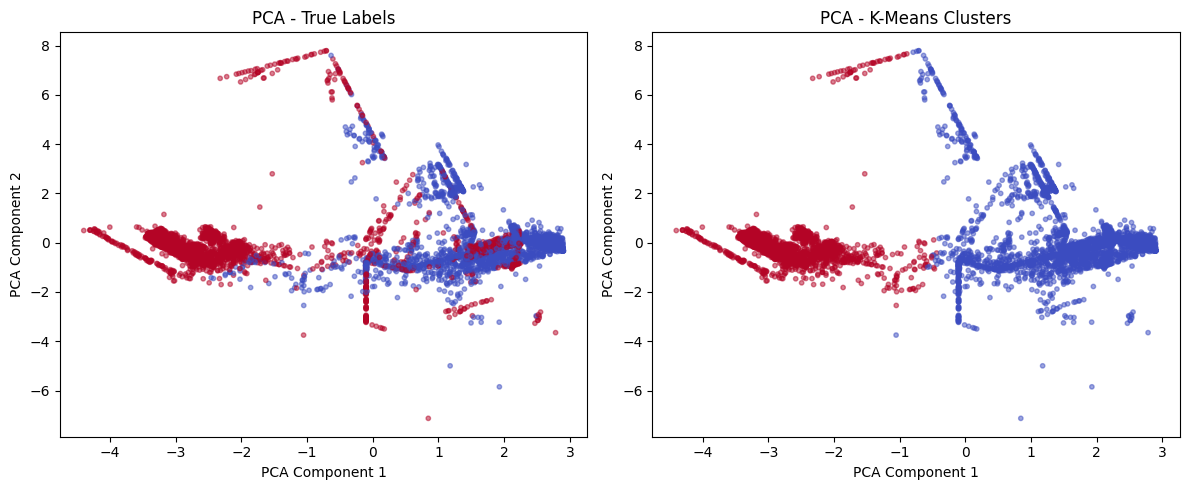

In [38]:
from sklearn.decomposition import PCA

# pca reduce 15 features to 2 so we can plot it
# only using pca for visualization not for clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left plot colored by real label
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=true_labels, cmap='coolwarm', alpha=0.5, s=10)
axes[0].set_title('PCA - True Labels')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# right plot colored by cluster id from kmeans
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('PCA - K-Means Clusters')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.savefig('task4_pca_clusters', bbox_inches='tight')
plt.show()


# Task 5: Genetic algorithm for feature sel.

In [28]:
import random

# settings for the GA
CHROM_LENGTH  = 15    # 15 features so chromosome lenght is 15
POP_SIZE      = 10    # population size
MAX_GENS      = 10    # how many generation to run
MUTATION_RATE = 0.05  # small chance to flip a bit
CROSSOVER_RATE= 0.8   # 80% chance to do crossover

# get feature names from X
feature_names = list(X.columns)
print("Features:", feature_names)


Features: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised', 'count', 'srv_count', 'serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'predicted']


In [29]:
# same create_chromosome from lab manual
# chromosome is list of 0s and 1s , 1 means use this feature
def create_chromosome(length):
    chrom = []   # start empty
    for i in range(length):
        bit = random.randint(0, 1)   # randomly 0 or 1
        chrom.append(bit)
    return chrom


In [30]:
# fitness function
# higher accuracy = better fitness = better chromosome
def fitness(chromosome):
    # find features where bit is 1
    selected = []
    for i in range(len(chromosome)):
        if chromosome[i] == 1:
            selected.append(feature_names[i])

    # if no feature is selected return 0
    if len(selected) == 0:
        return 0

    # train logistic regression using only selected features
    X_train_sel = pd.DataFrame(X_train_scaled, columns=feature_names)[selected]
    X_test_sel  = pd.DataFrame(X_test_scaled,  columns=feature_names)[selected]

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_sel, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_sel))
    return acc   # accuracy is the fitness score


In [31]:
# roulette wheel selection same as lab manual
# better fitness = bigger slice of wheel = more chance to be picked
def select_parent(population, scores):
    total = 0
    for s in scores:
        total = total + s   # sum all scores

    spin = random.uniform(0, total)   # random spin

    # walk through and find where spin lands
    running_sum = 0
    for i in range(len(population)):
        running_sum = running_sum + scores[i]
        if spin <= running_sum:
            return population[i]

    return population[-1]   # fallback just incase


In [32]:
# single point crossover same as lab manual
# cut both parents at random point and swap tails
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)   # random cut point

    # left of parent1 + right of parent2
    child1 = parent1[:point] + parent2[point:]

    # left of parent2 + right of parent1
    child2 = parent2[:point] + parent1[point:]

    return child1, child2


In [33]:
# bit flip mutation same as lab manual
# each bit has small chance to flip
def mutate(chromosome, rate):
    new_chrom = []
    for gene in chromosome:
        if random.random() < rate:   # if random number is less than rate
            if gene == 0:
                new_chrom.append(1)  # flip 0 to 1
            else:
                new_chrom.append(0)  # flip 1 to 0
        else:
            new_chrom.append(gene)   # keep same
    return new_chrom


In [36]:
# create starting population of 10 random chromosomes
population = []
for i in range(POP_SIZE):
    c = create_chromosome(CHROM_LENGTH)
    population.append(c)

best_chrom = population[0]
best_score = 0

# run GA for MAX_GENS generations
for gen in range(MAX_GENS):

    # calculate fitness for every chromosome in population
    scores = []
    for c in population:
        scores.append(fitness(c))

    # find the best one in this generation
    for i in range(len(population)):
        if scores[i] > best_score:
            best_score = scores[i]
            best_chrom = population[i]

    print(f"Gen {gen} | Best fitness: {round(best_score*100, 2)}% | Features used: {sum(best_chrom)}")

    # stop if perfect accuracy
    if best_score == 1.0:
        print("*** Perfect accuracy reached! ***")
        break

    # build new population using selection crossover mutation
    new_population = []

    while len(new_population) < POP_SIZE:
        p1 = select_parent(population, scores)   # pick parent 1
        p2 = select_parent(population, scores)   # pick parent 2

        if random.random() < CROSSOVER_RATE:
            child1, child2 = crossover(p1, p2)   # mix parents
        else:
            child1 = p1[:]   # copy if no crossover
            child2 = p2[:]

        # mutate the children a little bit
        child1 = mutate(child1, MUTATION_RATE)
        child2 = mutate(child2, MUTATION_RATE)

        new_population.append(child1)
        new_population.append(child2)

    # replace old population with new one
    population = new_population[:POP_SIZE]

print()
print("Final best chromosome:", best_chrom)
print(f"Best fitness (accuracy): {round(best_score*100, 2)}%")


Gen 0 | Best fitness: 89.25% | Features used: 9
Gen 1 | Best fitness: 89.25% | Features used: 9
Gen 2 | Best fitness: 89.67% | Features used: 9
Gen 3 | Best fitness: 89.83% | Features used: 7
Gen 4 | Best fitness: 90.25% | Features used: 10
Gen 5 | Best fitness: 90.25% | Features used: 10
Gen 6 | Best fitness: 90.25% | Features used: 10
Gen 7 | Best fitness: 90.42% | Features used: 11
Gen 8 | Best fitness: 90.42% | Features used: 11
Gen 9 | Best fitness: 90.42% | Features used: 11

Final best chromosome: [1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1]
Best fitness (accuracy): 90.42%


In [37]:
# show which features GA selected
print("=== Best Feature Subset Found by GA ===\n")
selected_features = []
for i in range(len(best_chrom)):
    if best_chrom[i] == 1:
        selected_features.append(feature_names[i])

print("Selected features :", selected_features)
print("Features selected :", len(selected_features), "out of 15")

# compare GA accuracy with using all features
all_features_acc = round(accuracy_score(y_test, y_pred_lr) * 100, 2)
ga_features_acc  = round(best_score * 100, 2)

print("\n=== Comparison ===")
print(f"Logistic Regression with ALL 15 features : {all_features_acc}%")
print(f"Logistic Regression with GA features     : {ga_features_acc}%")
print(f"Features reduced from 15 to {len(selected_features)}")


=== Best Feature Subset Found by GA ===

Selected features : ['duration', 'src_bytes', 'dst_bytes', 'hot', 'logged_in', 'count', 'srv_count', 'serror_rate', 'diff_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate']
Features selected : 11 out of 15

=== Comparison ===
Logistic Regression with ALL 15 features : 91.83%
Logistic Regression with GA features     : 90.42%
Features reduced from 15 to 11


# The End